# 1) Imports

#### PyTorch

In [2]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, OneCycleLR

In [3]:
print('PyTorch version', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

PyTorch version 2.9.1+cu128
Device: cuda


#### General

In [4]:
import os
import json
import math
import time
import random
from pathlib import Path
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from tqdm import tqdm

from sklearn.metrics import roc_auc_score

#### Monai

In [5]:
import monai
print("MONAI version:", monai.__version__)

/home/usrs/hnoel/miniconda3/envs/monai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MONAI version: 1.5.1


In [6]:
from monai.networks.nets import UNet as MonaiUNet
from monai.losses import DiceCELoss
from monai.utils import set_determinism
from monai.transforms import (
    Compose,
    RandFlipd,
    RandRotate90d,
    RandZoomd,
    RandAffined,
    RandGaussianNoised,
    RandShiftIntensityd,
    RandScaleIntensityd,
    EnsureTyped,
)

# 2) Parameters

#### 2.1) Directories

In [7]:
drive_root = Path("/home/usrs/hnoel/DRIVE_608")

# TRAIN = 20 images (21–40)
train_images_dir = drive_root / "training" / "images"
train_manual_dir = drive_root / "training" / "1st_manual"   # 21_manual1.gif, ...
train_fov_dir    = drive_root / "training" / "mask"        # 21_training_mask.tif, ...

# TEST = 20 images (01–20)
test_images_dir  = drive_root / "test" / "images"
test_manual_dir  = drive_root / "test" / "1st_manual"       # 01_manual1.gif, ...
test_fov_dir     = drive_root / "test" / "mask" 

#### 2.2) Hyperparameters

In [8]:
# Image sizes
IMG_HEIGHT = 608
IMG_WIDTH  = 608

# Batch size
BATCH_SIZE = 4

# Number of epochs
EPOCHS = 300

# Learning rate
LR = 1e-3

# Classes
NUM_CLASSES = 2
BACKGROUND_IDX = 0
VESSEL_CLASS = 1

#### 2.3) Seed

In [9]:
SEED = 42

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Monai
set_determinism(seed=SEED)

print(f"Seed fixed to {SEED}")

Seed fixed to 42


#### 2.4) Save directories

In [10]:
model_name = "UUNET_DRIVE_v1"

# Courbes, JSON, figures, etc.
data_dir = Path("/home/usrs/hnoel/Tohoku/Monai/UUNET") / model_name
data_dir.mkdir(parents=True, exist_ok=True)

# Poids de modèles
models_dir = Path("/home/usrs/hnoel/MODELS/UUNET") / model_name
models_dir.mkdir(parents=True, exist_ok=True)

# 3) DataLoaders

#### 3.1) Data augmentation

In [11]:
from monai.transforms import (
    Compose,
    ScaleIntensityd,
    RandFlipd,
    RandRotated,
    RandAffined,
    Resized,
    EnsureTyped,
)
import numpy as np

# ================
# TRANSFORMATIONS
# ================

# Toujours imposer (H,W) à la fin à cause des rotations sur images non carrées
final_size = (IMG_HEIGHT, IMG_WIDTH)   # (584, 565)

train_transforms = Compose([

    # Normalisation sur image uniquement
    ScaleIntensityd(keys=["image"]),

    # ---- AUGMENTATIONS ----
    RandFlipd(keys=["image", "label", "fov"], spatial_axis=0, prob=0.6),
    RandFlipd(keys=["image", "label", "fov"], spatial_axis=1, prob=0.6),

    RandRotated(
        keys=["image", "label", "fov"],
        range_x=np.pi/8,        # ±22.5°
        prob=0.3,
        mode=("bilinear", "nearest", "nearest"),
    ),

    RandAffined(
        keys=["image", "label", "fov"],
        prob=0.3,
        rotate_range=(-np.pi/12, np.pi/12),
        translate_range=(20, 20),
        scale_range=(0.05, 0.05),
        mode=("bilinear", "nearest", "nearest"),
    ),

    # ---- Fix dimension finale ----
    Resized(
        keys=["image", "label", "fov"],
        spatial_size=final_size,
        mode=("bilinear", "nearest", "nearest"),
    ),

    EnsureTyped(keys=["image", "label", "fov"]),
])

# -------------------
# Validation / Test
# -------------------

val_transforms = Compose([
    ScaleIntensityd(keys=["image"]),
    Resized(
        keys=["image", "label", "fov"],
        spatial_size=final_size,
        mode=("bilinear", "nearest", "nearest"),
    ),
    EnsureTyped(keys=["image", "label", "fov"]),
])


#### 3.2) Create the class fot the DRIVE datset images

In [12]:
class DriveDataset(Dataset):
    def __init__(self, img_dir, manual_dir, fov_dir,
                 img_size=(IMG_HEIGHT, IMG_WIDTH),
                 transforms=None,
                 indices=None):
        self.img_paths = sorted(list(Path(img_dir).glob("*.tif")))
        self.manual_dir = Path(manual_dir)
        self.fov_dir    = Path(fov_dir)
        self.H, self.W  = img_size   # H=584, W=565
        self.transforms = transforms
        self.indices    = indices

    def __len__(self):
        if self.indices is None:
            return len(self.img_paths)
        return len(self.indices)

    def _get_paths(self, idx):
        if self.indices is not None:
            idx = self.indices[idx]

        img_path = self.img_paths[idx]
        base = img_path.stem              # ex: "21_training"
        num  = base.split("_")[0]

        manual_path = self.manual_dir / f"{num}_manual1.gif"

        candidates = list(self.fov_dir.glob(f"{base}_mask.*"))
        if len(candidates) == 0:
            raise FileNotFoundError(f"No FOV mask found for {base} in {self.fov_dir}")
        fov_path = candidates[0]

        return img_path, manual_path, fov_path

    def __getitem__(self, idx):
        img_path, manual_path, fov_path = self._get_paths(idx)

        H, W = self.H, self.W   # force : (584, 565)

        # === Image ===
        img = Image.open(img_path).convert("RGB")
        img = img.resize((W, H), Image.BILINEAR)   # FORCE SHAPE (W,H)
        img_np = np.array(img).astype(np.float32) / 255.0
        img_t  = torch.from_numpy(img_np).permute(2, 0, 1)  # (3,H,W)

        # === GT vessels ===
        gt = Image.open(manual_path).convert("L")
        gt = gt.resize((W, H), Image.NEAREST)
        gt_np = np.array(gt)
        label_np = np.zeros_like(gt_np, dtype=np.int64)
        label_np[gt_np > 0] = VESSEL_CLASS
        label_t = torch.from_numpy(label_np).long().unsqueeze(0)

        # === FOV ===
        fov = Image.open(fov_path).convert("L")
        fov = fov.resize((W, H), Image.NEAREST)
        fov_np = (np.array(fov) > 0).astype(np.uint8)
        fov_t = torch.from_numpy(fov_np).long().unsqueeze(0)

        sample = {"image": img_t, "label": label_t, "fov": fov_t}

        if self.transforms is not None:
            sample = self.transforms(sample)

        return sample

In [13]:
# ========= Préparation des indices train / val sur TRAINING (21–40) =========
train_img_paths_all = sorted(list(Path(train_images_dir).glob("*.tif")))
train_nums = [int(p.stem.split("_")[0]) for p in train_img_paths_all]

"""
Validation on 22, 29, 31, 35
22 = Côtes d'Armor 
29 = Finistère
31 = Haute-Garonne
35 = Ille-et-Vilaine
"""
val_nums = {22, 29, 31, 35}
val_indices = [i for i, n in enumerate(train_nums) if n in val_nums]
train_indices = [i for i, n in enumerate(train_nums) if n not in val_nums]

print("Train indices (image numbers):", [train_nums[i] for i in train_indices])
print("Val indices (image numbers):  ", [train_nums[i] for i in val_indices])

# ========= Datasets =========
train_ds = DriveDataset(
    train_images_dir,
    train_manual_dir,
    train_fov_dir,
    img_size=(IMG_HEIGHT, IMG_WIDTH),
    transforms=train_transforms,
    indices=train_indices,
)

val_ds = DriveDataset(
    train_images_dir,
    train_manual_dir,
    train_fov_dir,
    img_size=(IMG_HEIGHT, IMG_WIDTH),
    transforms=val_transforms,
    indices=val_indices,
)

test_ds = DriveDataset(
    test_images_dir,
    test_manual_dir,
    test_fov_dir,
    img_size=(IMG_HEIGHT, IMG_WIDTH),
    transforms=val_transforms,
    indices=None,
)

# ========= DataLoaders =========
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print("Train / Val / Test sizes:", len(train_ds), len(val_ds), len(test_ds))


Train indices (image numbers): [21, 23, 24, 25, 26, 27, 28, 30, 32, 33, 34, 36, 37, 38, 39, 40]
Val indices (image numbers):   [22, 29, 31, 35]
Train / Val / Test sizes: 16 4 20


# 4) UNet Model

In [14]:
# -------------------------
# Basic building blocks
# -------------------------
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, k: int = 3, p: int = 1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.act  = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            ConvBNReLU(in_ch, out_ch),
            ConvBNReLU(out_ch, out_ch),
        )

    def forward(self, x):
        return self.block(x)


def center_crop_to(x, ref):
    if x.shape[-2:] == ref.shape[-2:]:
        return x
    dh = x.shape[-2] - ref.shape[-2]
    dw = x.shape[-1] - ref.shape[-1]
    return x[:, :, dh // 2 : dh // 2 + ref.shape[-2], dw // 2 : dw // 2 + ref.shape[-1]]


class UpBlock(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2, bias=False)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        skip = center_crop_to(skip, x)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


# -------------------------
# Asymmetric mini-U-Net block (fixed)
# -------------------------
class AsymUNetBlock(nn.Module):
    """
    Descend from start_level to level 4, then ascend to target_level.
    Uses:
      - internal skips for levels >= start_level (created during this block's descent)
      - global skips for levels < start_level (created elsewhere, e.g., phase A)
    """
    def __init__(self, channels, start_level: int, target_level: int):
        super().__init__()
        assert 0 <= start_level <= 3
        assert 0 <= target_level <= 3
        self.channels = list(channels)
        self.start = start_level
        self.target = target_level

        self.pool = nn.MaxPool2d(2)

        # Down: map C_l -> C_{l+1} for l=start..3
        self.down_convs = nn.ModuleList([
            DoubleConv(self.channels[l], self.channels[l + 1])
            for l in range(start_level, 4)
        ])

        self.bottom = DoubleConv(self.channels[4], self.channels[4])

        # Up: 4 -> target, needing skips at levels 3..target
        self.up_blocks = nn.ModuleList([
            UpBlock(in_ch=self.channels[l], skip_ch=self.channels[l - 1], out_ch=self.channels[l - 1])
            for l in range(4, target_level, -1)
        ])

    def forward(self, x, global_skips: dict):
        # Build internal skips during descent
        internal_skips = {self.start: x}  # feature at start level

        cur = x
        for idx, l in enumerate(range(self.start, 4)):
            # go to level l+1
            cur = self.pool(cur)
            cur = self.down_convs[idx](cur)
            internal_skips[l + 1] = cur

        cur = self.bottom(cur)  # still level 4

        # Ascend to target level
        level = 4
        for up in self.up_blocks:
            next_level = level - 1

            # Prefer internal skips (available for >= start), otherwise global skips
            skip = internal_skips.get(next_level, None)
            if skip is None:
                skip = global_skips.get(next_level, None)

            if skip is None:
                raise KeyError(
                    f"Missing skip for level {next_level}. "
                    f"Internal: {sorted(internal_skips.keys())}, "
                    f"Global: {sorted(global_skips.keys())}"
                )

            cur = up(cur, skip)
            level = next_level

        return cur  # at level self.target


class DownToBottleneck(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.to4  = DoubleConv(channels[3], channels[4])
        self.bot  = DoubleConv(channels[4], channels[4])

    def forward(self, x3):
        x4 = self.pool(x3)
        x4 = self.to4(x4)
        x4 = self.bot(x4)
        return x4


# -------------------------
# UU-Net (your schedule)
# -------------------------
class UUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=2, channels=(64, 128, 256, 512, 1024)):
        super().__init__()
        self.channels = list(channels)

        self.stem = DoubleConv(in_channels, self.channels[0])

        # Phase A
        self.a0 = AsymUNetBlock(self.channels, start_level=0, target_level=1)
        self.a1 = AsymUNetBlock(self.channels, start_level=1, target_level=2)
        self.a2 = AsymUNetBlock(self.channels, start_level=2, target_level=3)
        self.a3 = DownToBottleneck(self.channels)

        # Phase B
        self.up4_to_3 = UpBlock(in_ch=self.channels[4], skip_ch=self.channels[3], out_ch=self.channels[3])
        self.b3 = AsymUNetBlock(self.channels, start_level=3, target_level=2)
        self.b2 = AsymUNetBlock(self.channels, start_level=2, target_level=1)
        self.b1 = AsymUNetBlock(self.channels, start_level=1, target_level=0)

        self.out_conv = nn.Conv2d(self.channels[0], out_channels, kernel_size=1)

    def forward(self, x):
        global_skips = {}

        # level 0
        x0 = self.stem(x)
        global_skips[0] = x0

        # Phase A progressively builds reference features at levels 1..3
        x1 = self.a0(x0, global_skips)
        global_skips[1] = x1

        x2 = self.a1(x1, global_skips)
        global_skips[2] = x2

        x3 = self.a2(x2, global_skips)
        global_skips[3] = x3

        x4 = self.a3(x3)  # level 4

        # Phase B
        y3 = self.up4_to_3(x4, global_skips[3])  # 4->3

        y2 = self.b3(y3, global_skips)  # needs global skip at level 2
        y1 = self.b2(y2, global_skips)  # needs global skip at level 1
        y0 = self.b1(y1, global_skips)  # needs global skip at level 0

        return self.out_conv(y0)


# -------------------------
# Sanity check
# -------------------------
if __name__ == "__main__":
    model = UUNet(in_channels=3, out_channels=2).to(device)
    x = torch.randn(2, 3, 608, 608).to(device)
    y = model(x)
    print("output:", y.shape)  # (2, 2, 608, 608)


output: torch.Size([2, 2, 608, 608])


In [15]:
print(model.__class__.__name__, "initialized on", device)

UUNet initialized on cuda


# 5) Optimizer

In [16]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-2
    )

# 6) Scheduler

In [17]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=50,   # tous les 50 epochs
    gamma=0.5       # LR = LR * 0.5
)

# 7) Loss function

In [18]:
# Pour DRIVE (binaire), on commence sans pondération explicite des classes.
# Si besoin, on pourra recalculer des poids plus tard à partir des fréquences de pixels.
weights = None

In [19]:
loss_function = DiceCELoss(
    include_background=False,   # on ne compte pas le background dans le Dice
    to_onehot_y=True,
    softmax=True,
    weight=weights,
    lambda_dice=1.0,
    lambda_ce=1.0,
)

# 8) History and metrics

In [20]:
best_val_loss = float("inf")
best_val_dice = -float("inf")

In [21]:
# ===========================================
#   DICTIONNAIRES STOCRAGE (MEAN ONLY)
# ===========================================

train_history = {
    "loss": [],
    "accuracy":   [],
    "dice":       [],
    "iou":        [],
    "precision":  [],
    "recall":     [],
    "sensitivity":[],
    "specificity":[],
    "auc":        [],
    "lr":         [],
    "alpha":      []
}

val_history = {
    "loss": [],
    "accuracy":   [],
    "dice":       [],
    "iou":        [],
    "precision":  [],
    "recall":     [],
    "sensitivity":[],
    "specificity":[],
    "auc":        []
}

In [22]:
def init_confmat_sums(num_classes=NUM_CLASSES):
    """
    Agrégats TP/FP/FN/TN sur l'ensemble du dataset.
    N = nombre de pixels pris en compte (dans le FOV).
    """
    sums = {
        "TP": np.zeros(num_classes, dtype=np.int64),
        "FP": np.zeros(num_classes, dtype=np.int64),
        "FN": np.zeros(num_classes, dtype=np.int64),
        "TN": np.zeros(num_classes, dtype=np.int64),
        "N":  0,
    }
    return sums

In [23]:
def init_auc_buffers(classes):
    """
    Buffers pour stocker y_true / y_score par classe (liste d'indices de classes).
    Exemple : classes = [VESSEL_CLASS].
    """
    buffers = {}
    for c in classes:
        buffers[c] = {"y_true": [], "y_score": []}
    return buffers

In [24]:
def update_confmat_sums(sums, preds, targets, num_classes=NUM_CLASSES, fov=None):
    """
    Mets à jour TP/FP/FN/TN en tenant compte éventuellement du FOV.
    - preds   : (B,H,W)
    - targets : (B,H,W) ou (B,1,H,W)
    - fov     : (B,H,W) ou (B,1,H,W), bool ou {0,1}; si None => tout le carré
    """
    with torch.no_grad():
        # Harmonisation des shapes
        if targets.dim() == 4:
            targets = targets.squeeze(1)          # (B,H,W)
        if fov is not None and fov.dim() == 4:
            fov = fov.squeeze(1)                  # (B,H,W)

        # Masque FOV binaire, si fourni
        if fov is not None:
            f = fov.bool()
        else:
            f = None

        for c in range(num_classes):
            p = (preds == c)
            t = (targets == c)

            if f is not None:
                p = p & f
                t = t & f

            tp = (p & t).sum().item()
            fp = (p & ~t).sum().item()
            fn = (~p & t).sum().item()
            tn = (~p & ~t).sum().item()

            sums["TP"][c] += tp
            sums["FP"][c] += fp
            sums["FN"][c] += fn
            sums["TN"][c] += tn

        if f is not None:
            sums["N"] += f.sum().item()
        else:
            sums["N"] += targets.numel()

In [25]:
def update_auc_buffers(buffers, logits, targets, fov=None):
    """
    Mets à jour les buffers pour AUC.
    - logits : (B,C,H,W)
    - targets: (B,H,W) ou (B,1,H,W)
    - fov    : (B,H,W) ou (B,1,H,W), bool ou {0,1}; si None => tout le carré
    """
    with torch.no_grad():
        if targets.dim() == 4:
            targets = targets.squeeze(1)          # (B,H,W)
        if fov is not None and fov.dim() == 4:
            fov = fov.squeeze(1)                  # (B,H,W)

        probs = F.softmax(logits, dim=1)          # (B,C,H,W)
        B, C, H, W = probs.shape

        # aplatir
        flat_probs = probs.permute(0, 2, 3, 1).reshape(-1, C)  # (B*H*W, C)
        flat_t     = targets.reshape(-1)                       # (B*H*W,)

        if fov is not None:
            flat_f = fov.reshape(-1).bool()
            flat_probs = flat_probs[flat_f]
            flat_t     = flat_t[flat_f]

        for c, pack in buffers.items():
            y_true  = (flat_t == c).cpu().numpy().astype(np.uint8)
            y_score = flat_probs[:, c].cpu().numpy()

            # cas dégénérés : pas de pos ou pas de neg => AUC non définie
            pos = (y_true == 1).sum()
            neg = (y_true == 0).sum()
            if pos == 0 or neg == 0:
                continue

            pack["y_true"].append(y_true)
            pack["y_score"].append(y_score)

In [26]:
def compute_scalar_metrics_from_confmat(sums, include_classes):
    """
    Calcule accuracy / precision / recall / specificity / dice / IoU
    en moyenne sur les classes listées (ex: [VESSEL_CLASS]).
    """
    TP, FP, FN, TN = sums["TP"], sums["FP"], sums["FN"], sums["TN"]
    eps = 1e-7

    acc_c  = (TP + TN) / np.maximum(TP + TN + FP + FN, eps)
    prec_c = TP / np.maximum(TP + FP, eps)
    rec_c  = TP / np.maximum(TP + FN, eps)
    spec_c = TN / np.maximum(TN + FP, eps)
    dice_c = (2 * TP) / np.maximum(2 * TP + FP + FN, eps)
    iou_c  = TP / np.maximum(TP + FP + FN, eps)

    idx = np.array(include_classes, dtype=int)
    return {
        "accuracy":    float(np.mean(acc_c[idx])),
        "precision":   float(np.mean(prec_c[idx])),
        "recall":      float(np.mean(rec_c[idx])),
        "specificity": float(np.mean(spec_c[idx])),
        "dice":        float(np.mean(dice_c[idx])),
        "iou":         float(np.mean(iou_c[idx])),
    }

In [27]:
def compute_mean_auc(buffers):
    """
    Calcule l'AUC moyen en moyennant sur les classes présentes dans `buffers`.
    """
    aucs = []
    for c, pack in buffers.items():
        if len(pack["y_true"]) == 0:
            continue
        y_true  = np.concatenate(pack["y_true"])
        y_score = np.concatenate(pack["y_score"])

        pos = (y_true == 1).sum()
        neg = (y_true == 0).sum()
        if pos == 0 or neg == 0:
            continue

        try:
            aucs.append(roc_auc_score(y_true, y_score))
        except Exception:
            pass

    if len(aucs) == 0:
        return float("nan")
    return float(np.mean(aucs))

# 9) Training

In [28]:
for epoch in range(EPOCHS):

    # =========================
    #        TRAIN
    # =========================
    model.train()

    running_loss = 0.0
    conf_sums = init_confmat_sums()
    auc_buf   = init_auc_buffers([VESSEL_CLASS])

    for batch in train_loader :

        imgs   = batch["image"].to(device, non_blocking=True)
        masks = batch["label"].to(device, non_blocking=True)
        fov    = batch["fov"].to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)  # (N,C,H,W)
        loss    = loss_function(outputs, masks)  # Dice + CE (MONAI)

        loss.backward()
        optimizer.step()

        batch_size = imgs.size(0)
        running_loss += loss.item() * batch_size

        preds = outputs.argmax(dim=1)
        update_confmat_sums(conf_sums, preds, masks, NUM_CLASSES)
        update_auc_buffers(auc_buf, outputs, masks)

    train_loss   = running_loss / len(train_ds)
    train_metrics = compute_scalar_metrics_from_confmat(conf_sums, [VESSEL_CLASS])
    train_auc     = compute_mean_auc(auc_buf)

    current_lr = optimizer.param_groups[0]["lr"]

    train_history["loss"].append(train_loss)
    train_history["accuracy"].append(train_metrics["accuracy"])
    train_history["dice"].append(train_metrics["dice"])
    train_history["iou"].append(train_metrics["iou"])
    train_history["precision"].append(train_metrics["precision"])
    train_history["recall"].append(train_metrics["recall"])
    train_history["specificity"].append(train_metrics["specificity"])
    train_history["auc"].append(train_auc)
    train_history["lr"].append(current_lr)

    # =========================
    #       VALIDATION
    # =========================
    model.eval()

    val_running_loss = 0.0
    conf_sums_val = init_confmat_sums()
    auc_buf_val   = init_auc_buffers(classes=[VESSEL_CLASS])

    with torch.no_grad():
        for batch in val_loader :

            imgs   = batch["image"].to(device, non_blocking=True)
            masks = batch["label"].to(device, non_blocking=True)
            fov    = batch["fov"].to(device, non_blocking=True)

            outputs = model(imgs)
            loss    = loss_function(outputs, masks)

            batch_size = imgs.size(0)
            val_running_loss += loss.item() * batch_size

            preds = outputs.argmax(dim=1)
            update_confmat_sums(conf_sums_val, preds, masks, NUM_CLASSES)
            update_auc_buffers(auc_buf_val, outputs, masks)

    val_loss    = val_running_loss / len(val_ds)
    val_metrics = compute_scalar_metrics_from_confmat(conf_sums_val, [VESSEL_CLASS])
    val_auc     = compute_mean_auc(auc_buf_val)

    val_history["loss"].append(val_loss)
    val_history["accuracy"].append(val_metrics["accuracy"])
    val_history["dice"].append(val_metrics["dice"])
    val_history["iou"].append(val_metrics["iou"])
    val_history["precision"].append(val_metrics["precision"])
    val_history["recall"].append(val_metrics["recall"])
    val_history["specificity"].append(val_metrics["specificity"])
    val_history["auc"].append(val_auc)

    # =========================
    #        LOGS
    # =========================
    print("-" * 40)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}")
    print(f"  Train Dice: {train_metrics['dice']:.4f} | Val Dice: {val_metrics['dice']:.4f}")
    print(f"  Current LR: {current_lr:.6f}")

    # =========================
    #   SAVE BEST MODELS
    # =========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), str(models_dir / "loss_best_model_state_dict.pth"))
        torch.save(model,              str(models_dir / "loss_best_model_full.pth"))
        print("✅ New best model (loss) saved")

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), str(models_dir / "dice_best_model_state_dict.pth"))
        torch.save(model,              str(models_dir / "dice_best_model_full.pth"))
        print("✅ New best model (dice) saved")

    # =========================
    #   SCHEDULER STEP
    # =========================
    scheduler.step()

# =========================
#     SAVE LAST MODEL
# =========================
torch.save(model.state_dict(), str(models_dir / f"epoch{EPOCHS}_model_state_dict.pth"))
torch.save(model,              str(models_dir / f"epoch{EPOCHS}_model_full.pth"))
print("✅ Last model saved")


----------------------------------------
Epoch 1/300
  Train Loss: 1.3686
  Val   Loss: 1.5140
  Train Dice: 0.2201 | Val Dice: 0.0000
  Current LR: 0.001000
✅ New best model (loss) saved
✅ New best model (dice) saved
----------------------------------------
Epoch 2/300
  Train Loss: 1.1599
  Val   Loss: 1.4667
  Train Dice: 0.3321 | Val Dice: 0.0000
  Current LR: 0.001000
✅ New best model (loss) saved
----------------------------------------
Epoch 3/300
  Train Loss: 1.0735
  Val   Loss: 26.7508
  Train Dice: 0.3954 | Val Dice: 0.1235
  Current LR: 0.001000
✅ New best model (dice) saved
----------------------------------------
Epoch 4/300
  Train Loss: 1.0045
  Val   Loss: 11.9465
  Train Dice: 0.4400 | Val Dice: 0.1411
  Current LR: 0.001000
✅ New best model (dice) saved
----------------------------------------
Epoch 5/300
  Train Loss: 0.9231
  Val   Loss: 1.3560
  Train Dice: 0.5518 | Val Dice: 0.1270
  Current LR: 0.001000
✅ New best model (loss) saved
----------------------------

In [29]:
with open(data_dir / "UNet_train_history.json", "w") as f:
    json.dump(train_history, f, indent=4)

with open(data_dir / "UNet_val_history.json", "w") as f:
    json.dump(val_history, f, indent=4)

print("Historiques sauvegardés en JSON")

Historiques sauvegardés en JSON


# 10) Validation tests

#### 10.1) Load the model

In [30]:
model.load_state_dict(torch.load(models_dir / "dice_best_model_state_dict.pth", map_location=device, weights_only=True))
model.eval()

UUNet(
  (stem): DoubleConv(
    (block): Sequential(
      (0): ConvBNReLU(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU(inplace=True)
      )
      (1): ConvBNReLU(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU(inplace=True)
      )
    )
  )
  (a0): AsymUNetBlock(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (down_convs): ModuleList(
      (0): DoubleConv(
        (block): Sequential(
          (0): ConvBNReLU(
            (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (a

#### 10.2) Images

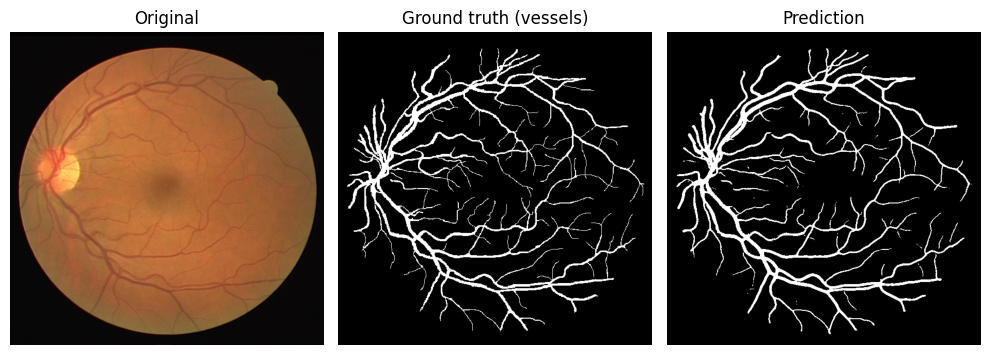

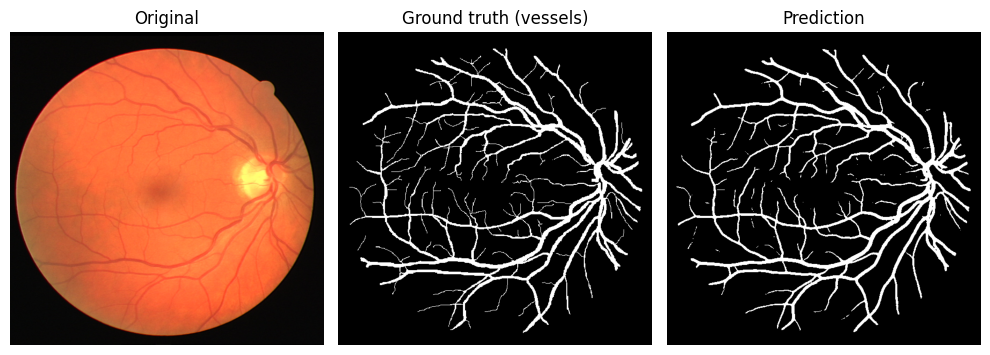

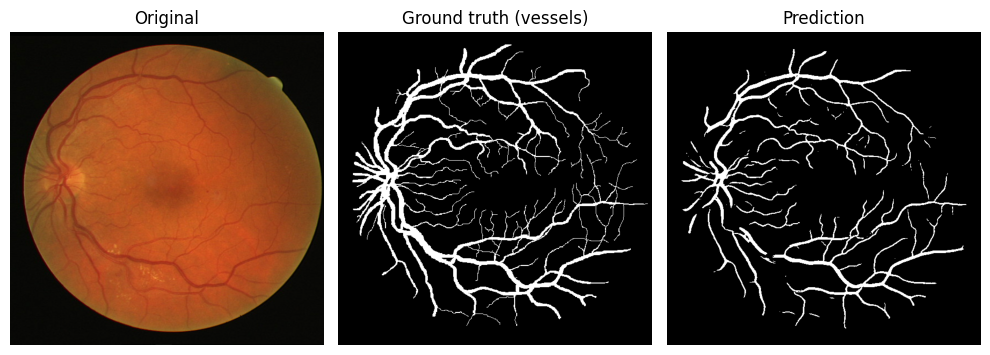

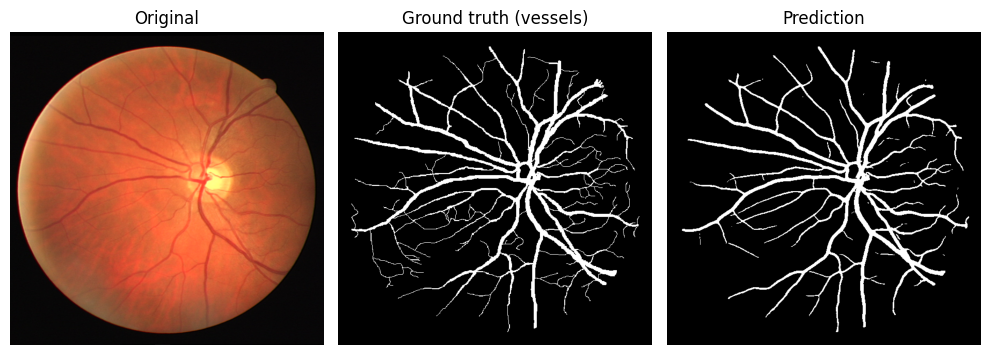

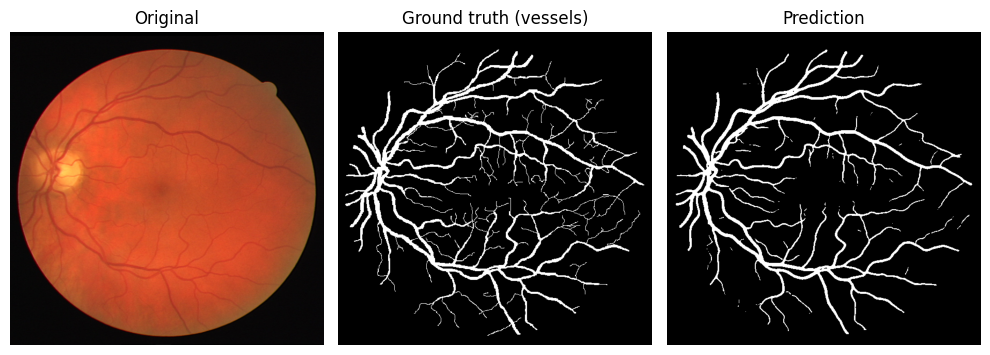

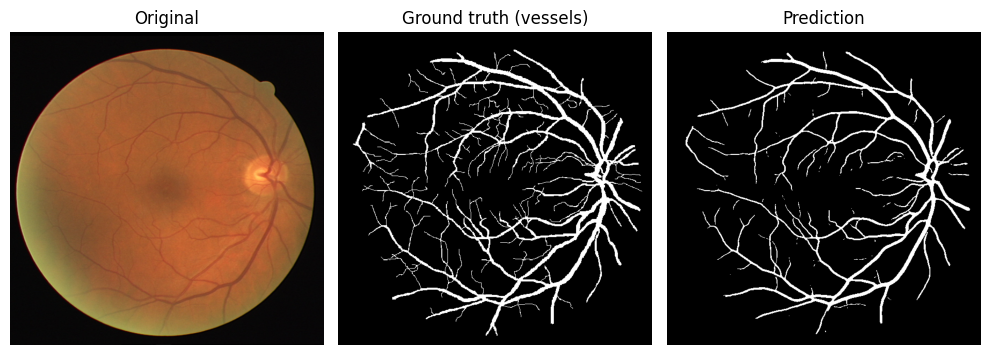

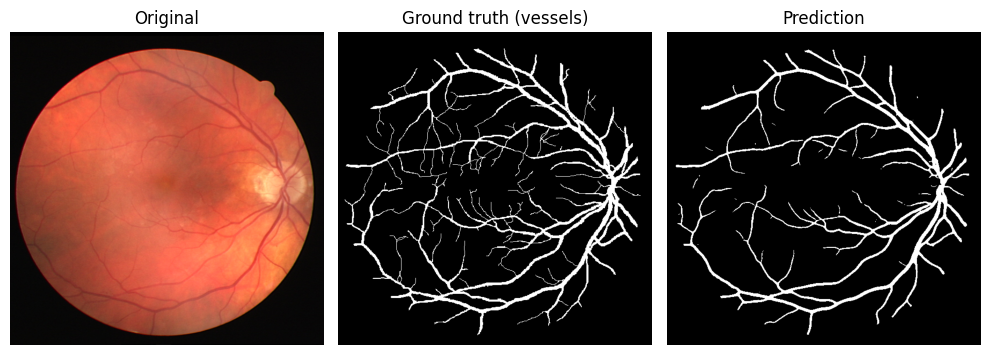

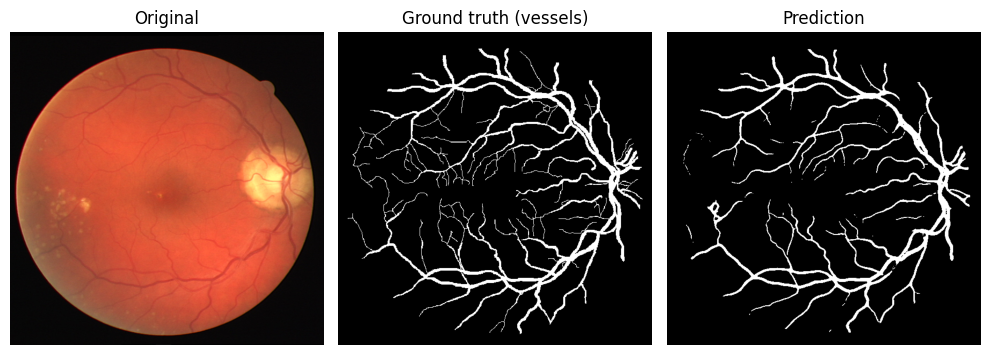

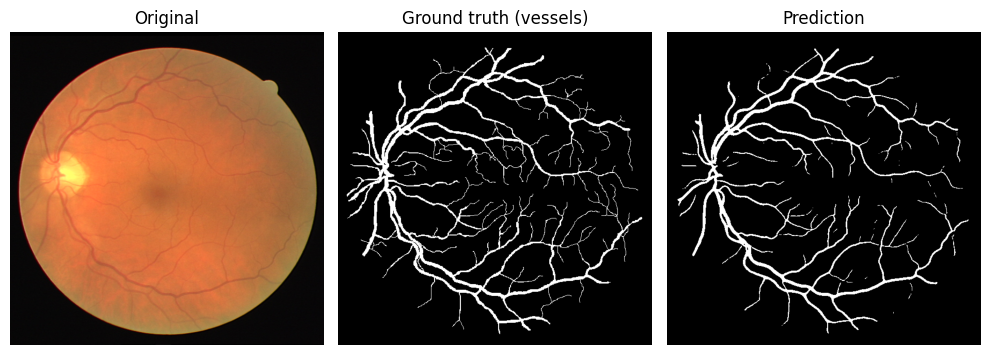

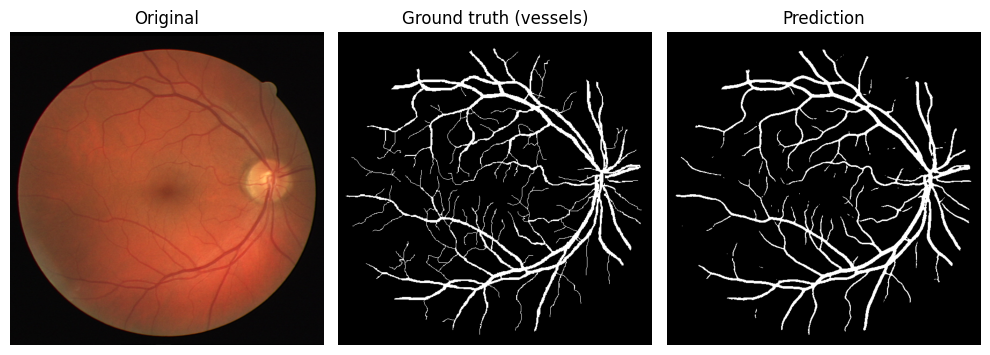

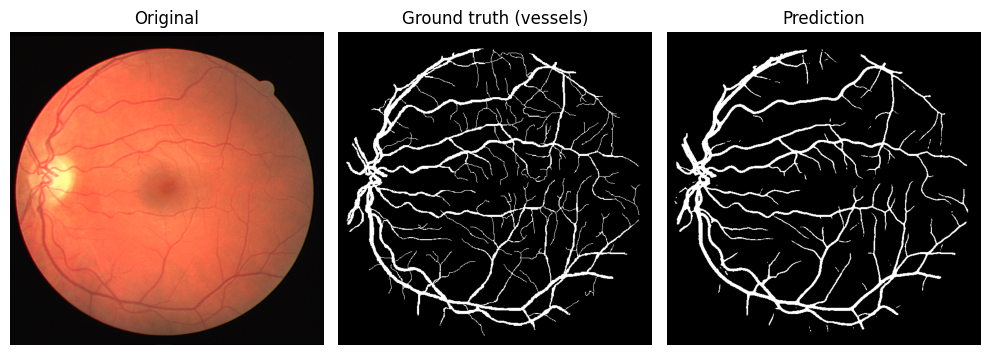

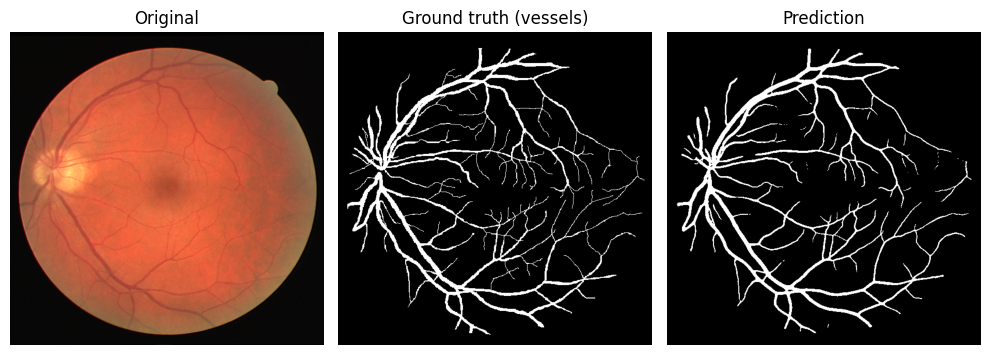

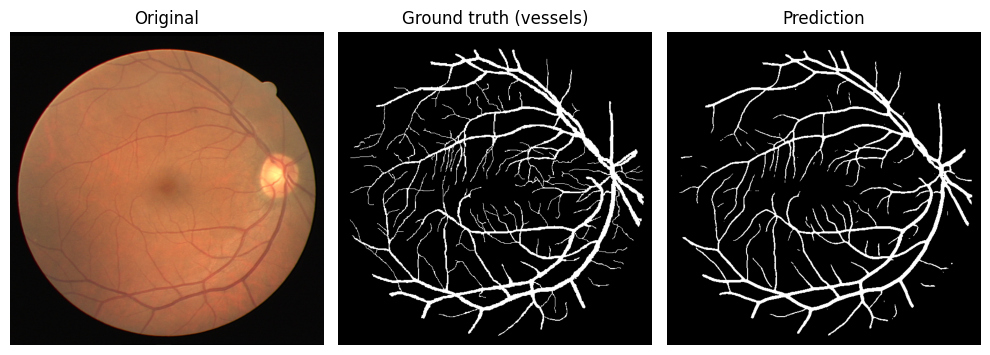

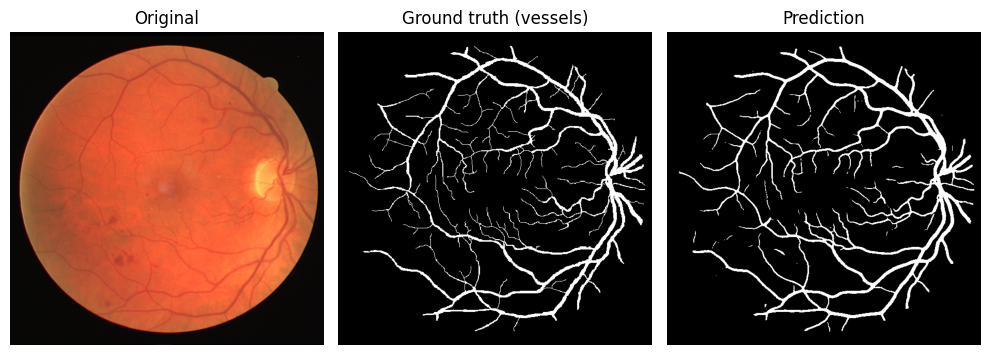

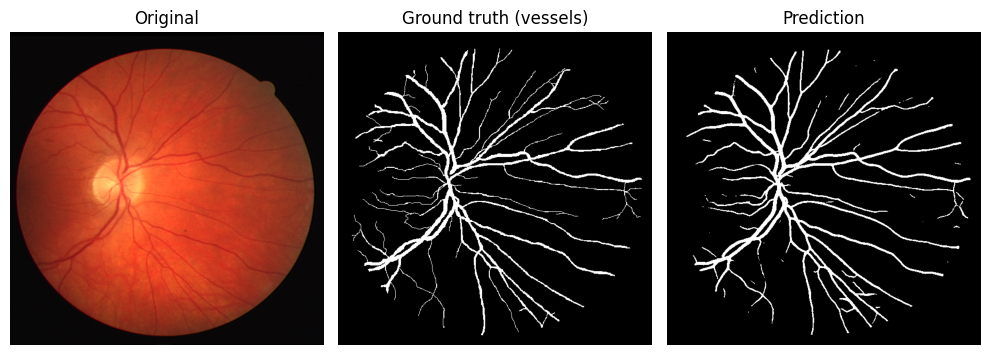

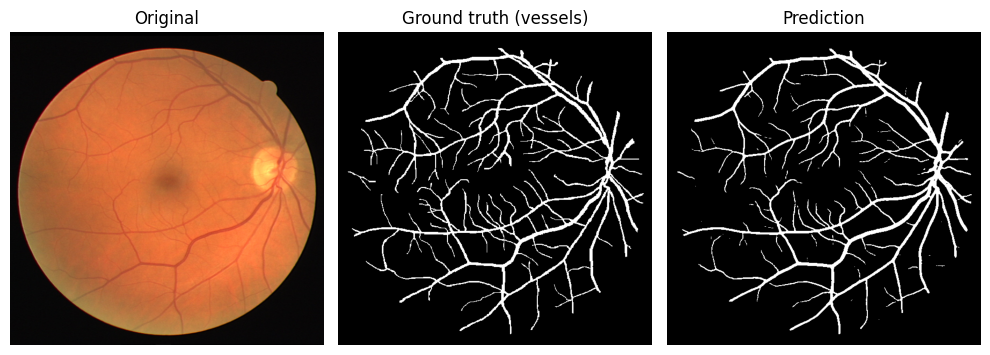

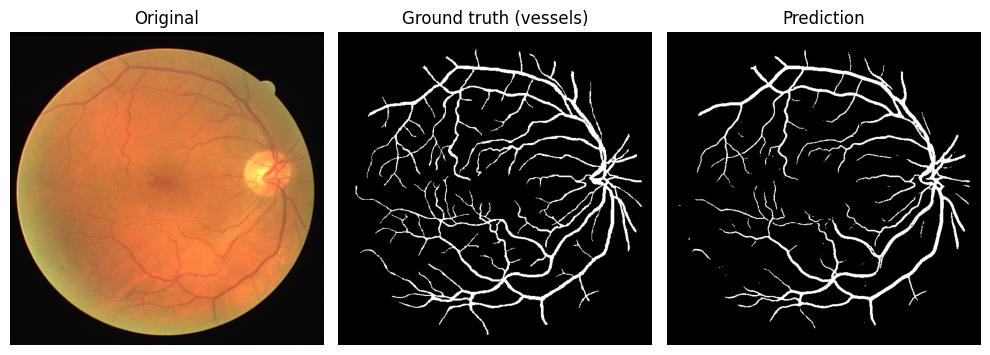

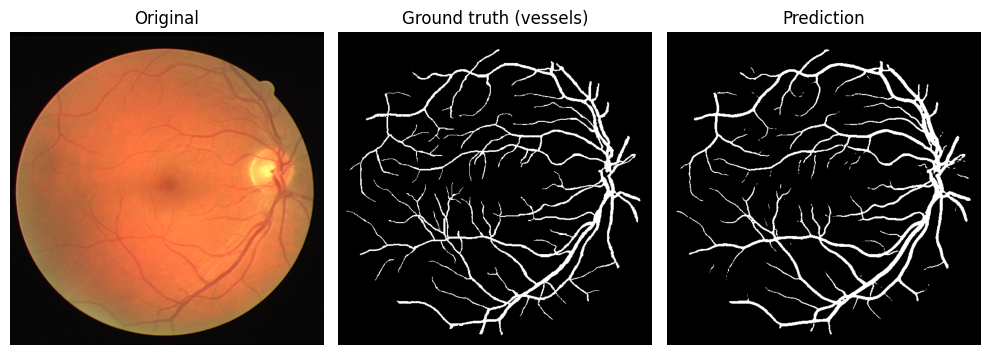

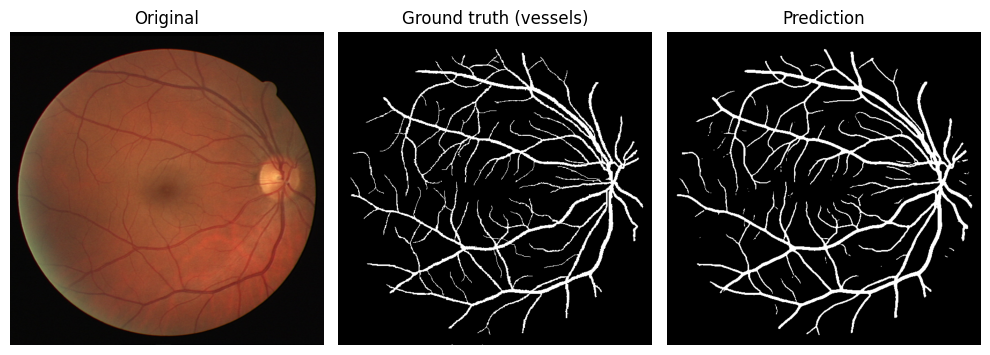

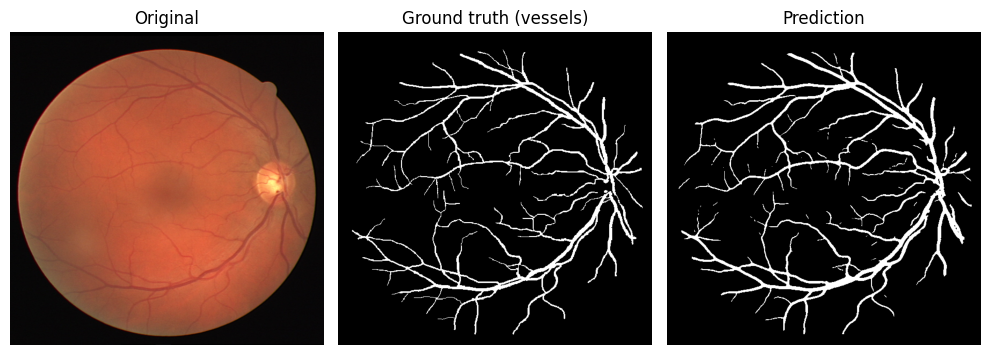

Triplets sauvegardés dans : /home/usrs/hnoel/Tohoku/Monai/UUNET/UUNET_DRIVE_v1/predictions_test_triplets


In [31]:
model.eval()

# 📁 Dossier pour sauvegarder les triplets
pred_dir = data_dir / "predictions_test_triplets"
pred_dir.mkdir(parents=True, exist_ok=True)

img_index = 0

with torch.no_grad():
    for batch in test_loader:
        imgs   = batch["image"].to(device)  # (B,3,H,W)
        labels = batch["label"].to(device)  # (B,1,H,W)

        logits = model(imgs)
        if isinstance(logits, list):
                logits = logits[0]                # (B,2,H,W)
        preds  = logits.argmax(dim=1)       # (B,H,W)
        targets = labels.squeeze(1)         # (B,H,W)

        for i in range(imgs.size(0)):
            img_i  = imgs[i].cpu()
            gt_i   = targets[i].cpu()
            pred_i = preds[i].cpu()

            fig, ax = plt.subplots(1, 3, figsize=(10, 4))

            ax[0].imshow(img_i.permute(1, 2, 0))
            ax[0].set_title("Original")

            ax[1].imshow(gt_i, cmap="gray")
            ax[1].set_title("Ground truth (vessels)")

            ax[2].imshow(pred_i, cmap="gray")
            ax[2].set_title("Prediction")

            for a in ax:
                a.axis("off")

            plt.tight_layout()

            save_path = pred_dir / f"test_triplet_{img_index:02d}.png"
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            plt.show()

            img_index += 1

print(f"Triplets sauvegardés dans : {pred_dir}")

#### 10.3) Curves

In [32]:
def plot_metric(train_history, val_history, key, title=None, mark_best_on="val_loss", save_folder=data_dir):
    """
    key: nom de la métrique dans les dicts (ex: "loss", "dice", "auc")

    mark_best_on:
        - "val_loss" → marquer l'epoch où val_loss est minimal
        - "val_<key>" → marquer la meilleure valeur validation pour cette métrique (max)
    """

    train = train_history.get(key, [])
    val   = val_history.get(key, [])

    if len(val) == 0:
        print(f"⚠️ Impossible de tracer '{key}' (aucune valeur de validation trouvée)")
        return

    epochs = range(1, len(val) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, train, label=f"Train {key}", linewidth=2)
    plt.plot(epochs, val,   label=f"Val {key}", linewidth=2)

    # ======== BEST POINT (scatter) =========
    if mark_best_on == "val_loss" and "loss" in val_history:
        # meilleur = minimum
        best_e = int(np.argmin(val_history["loss"])) + 1
        best_v = val[best_e - 1]
        plt.scatter([best_e], [best_v], s=80, marker="o", color="red", zorder=3,
                    label=f"best @ epoch {best_e}")

    elif mark_best_on == f"val_{key}" and len(val) > 0:
        # meilleur = maximum
        best_e = int(np.nanargmax(val)) + 1
        best_v = val[best_e - 1]
        plt.scatter([best_e], [best_v], s=80, marker="o", color="red", zorder=3,
                    label=f"best @ epoch {best_e}")

    plt.xlabel("Epoch")
    plt.ylabel(key)
    plt.title(title or f"{key} (train vs val)")
    plt.grid(True)
    plt.legend()

    save_path = save_folder / f"{key}.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"💾 Courbe sauvegardée : {save_path}")

    plt.show()

💾 Courbe sauvegardée : /home/usrs/hnoel/Tohoku/Monai/UUNET/UUNET_DRIVE_v1/loss.png


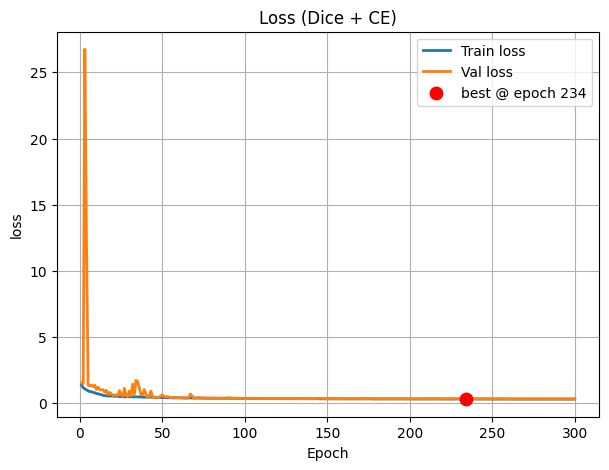

💾 Courbe sauvegardée : /home/usrs/hnoel/Tohoku/Monai/UUNET/UUNET_DRIVE_v1/dice.png


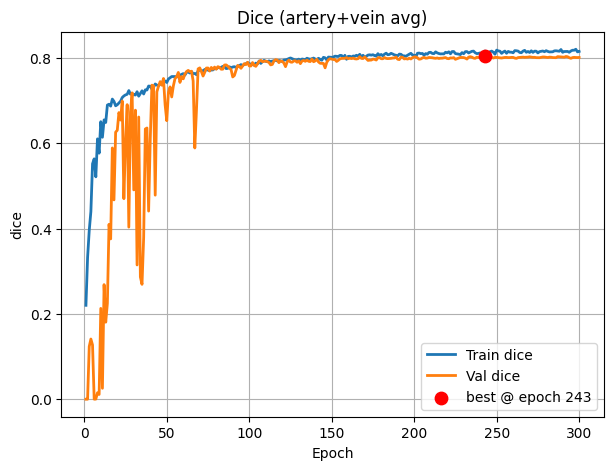

💾 Courbe sauvegardée : /home/usrs/hnoel/Tohoku/Monai/UUNET/UUNET_DRIVE_v1/auc.png


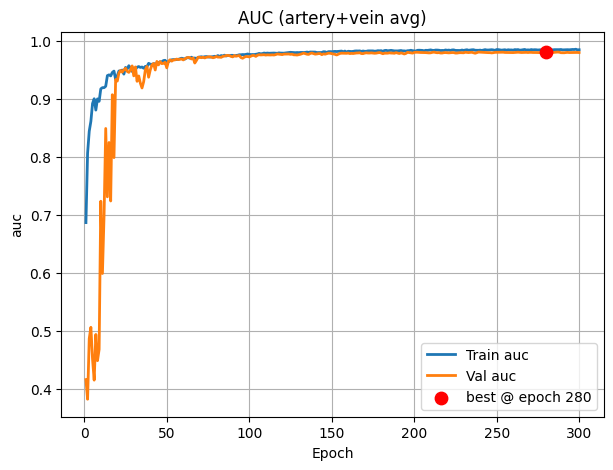

In [33]:
# Loss totale, Dice, AUC : même type de visualisation que dans ton notebook

plot_metric(train_history, val_history, "loss",
            title="Loss (Dice + CE)", mark_best_on="val_loss")

plot_metric(train_history, val_history, "dice",
            title="Dice (artery+vein avg)", mark_best_on="val_dice")

plot_metric(train_history, val_history, "auc",
            title="AUC (artery+vein avg)", mark_best_on="val_auc")

#### 10.3) Table of metrics

In [34]:
# ==== Évaluation globale sur le test ====

model.eval()

conf_sums_test = init_confmat_sums(num_classes=NUM_CLASSES)
auc_buf_test   = init_auc_buffers(classes=[VESSEL_CLASS])

with torch.no_grad():
    for batch in test_loader:
        imgs   = batch["image"].to(device)
        labels = batch["label"].to(device)   # (B,1,H,W)

        logits = model(imgs)
        if isinstance(logits, list):
                logits = logits[0]                 # (B,2,H,W)
        preds  = logits.argmax(dim=1)        # (B,H,W)
        targets = labels.squeeze(1)          # (B,H,W)

        update_confmat_sums(conf_sums_test, preds, targets, NUM_CLASSES)
        update_auc_buffers(auc_buf_test, logits, targets)

vessel_metrics = compute_scalar_metrics_from_confmat(conf_sums_test, include_classes=[VESSEL_CLASS])
vessel_auc     = compute_mean_auc(auc_buf_test)

results = {
    "Vessel": {
        "accuracy":    vessel_metrics["accuracy"],
        "precision":   vessel_metrics["precision"],
        "recall":      vessel_metrics["recall"],
        "specificity": vessel_metrics["specificity"],
        "dice":        vessel_metrics["dice"],
        "IoU":         vessel_metrics["iou"],
        "AUC":         vessel_auc,
    }
}

df_global = pd.DataFrame(results).T.round(4)

print("\n=== Résultats globaux sur le test (FOV uniquement) ===\n")
display(df_global)

# Sauvegarde en CSV / JSON
metrics_csv_path  = data_dir / "metrics_global_test.csv"
metrics_json_path = data_dir / "metrics_global_test.json"

df_global.to_csv(metrics_csv_path)
df_global.to_json(metrics_json_path, orient="index")

print("→ Sauvegardé :")
print("  ", metrics_csv_path)
print("  ", metrics_json_path)


=== Résultats globaux sur le test (FOV uniquement) ===



,accuracy,precision,recall,specificity,dice,IoU,AUC
Vessel,0.9661,0.8161,0.7919,0.9829,0.8038,0.672,0.9806


→ Sauvegardé :
   /home/usrs/hnoel/Tohoku/Monai/UUNET/UUNET_DRIVE_v1/metrics_global_test.csv
   /home/usrs/hnoel/Tohoku/Monai/UUNET/UUNET_DRIVE_v1/metrics_global_test.json


#### 10.4) Comparaison of the images

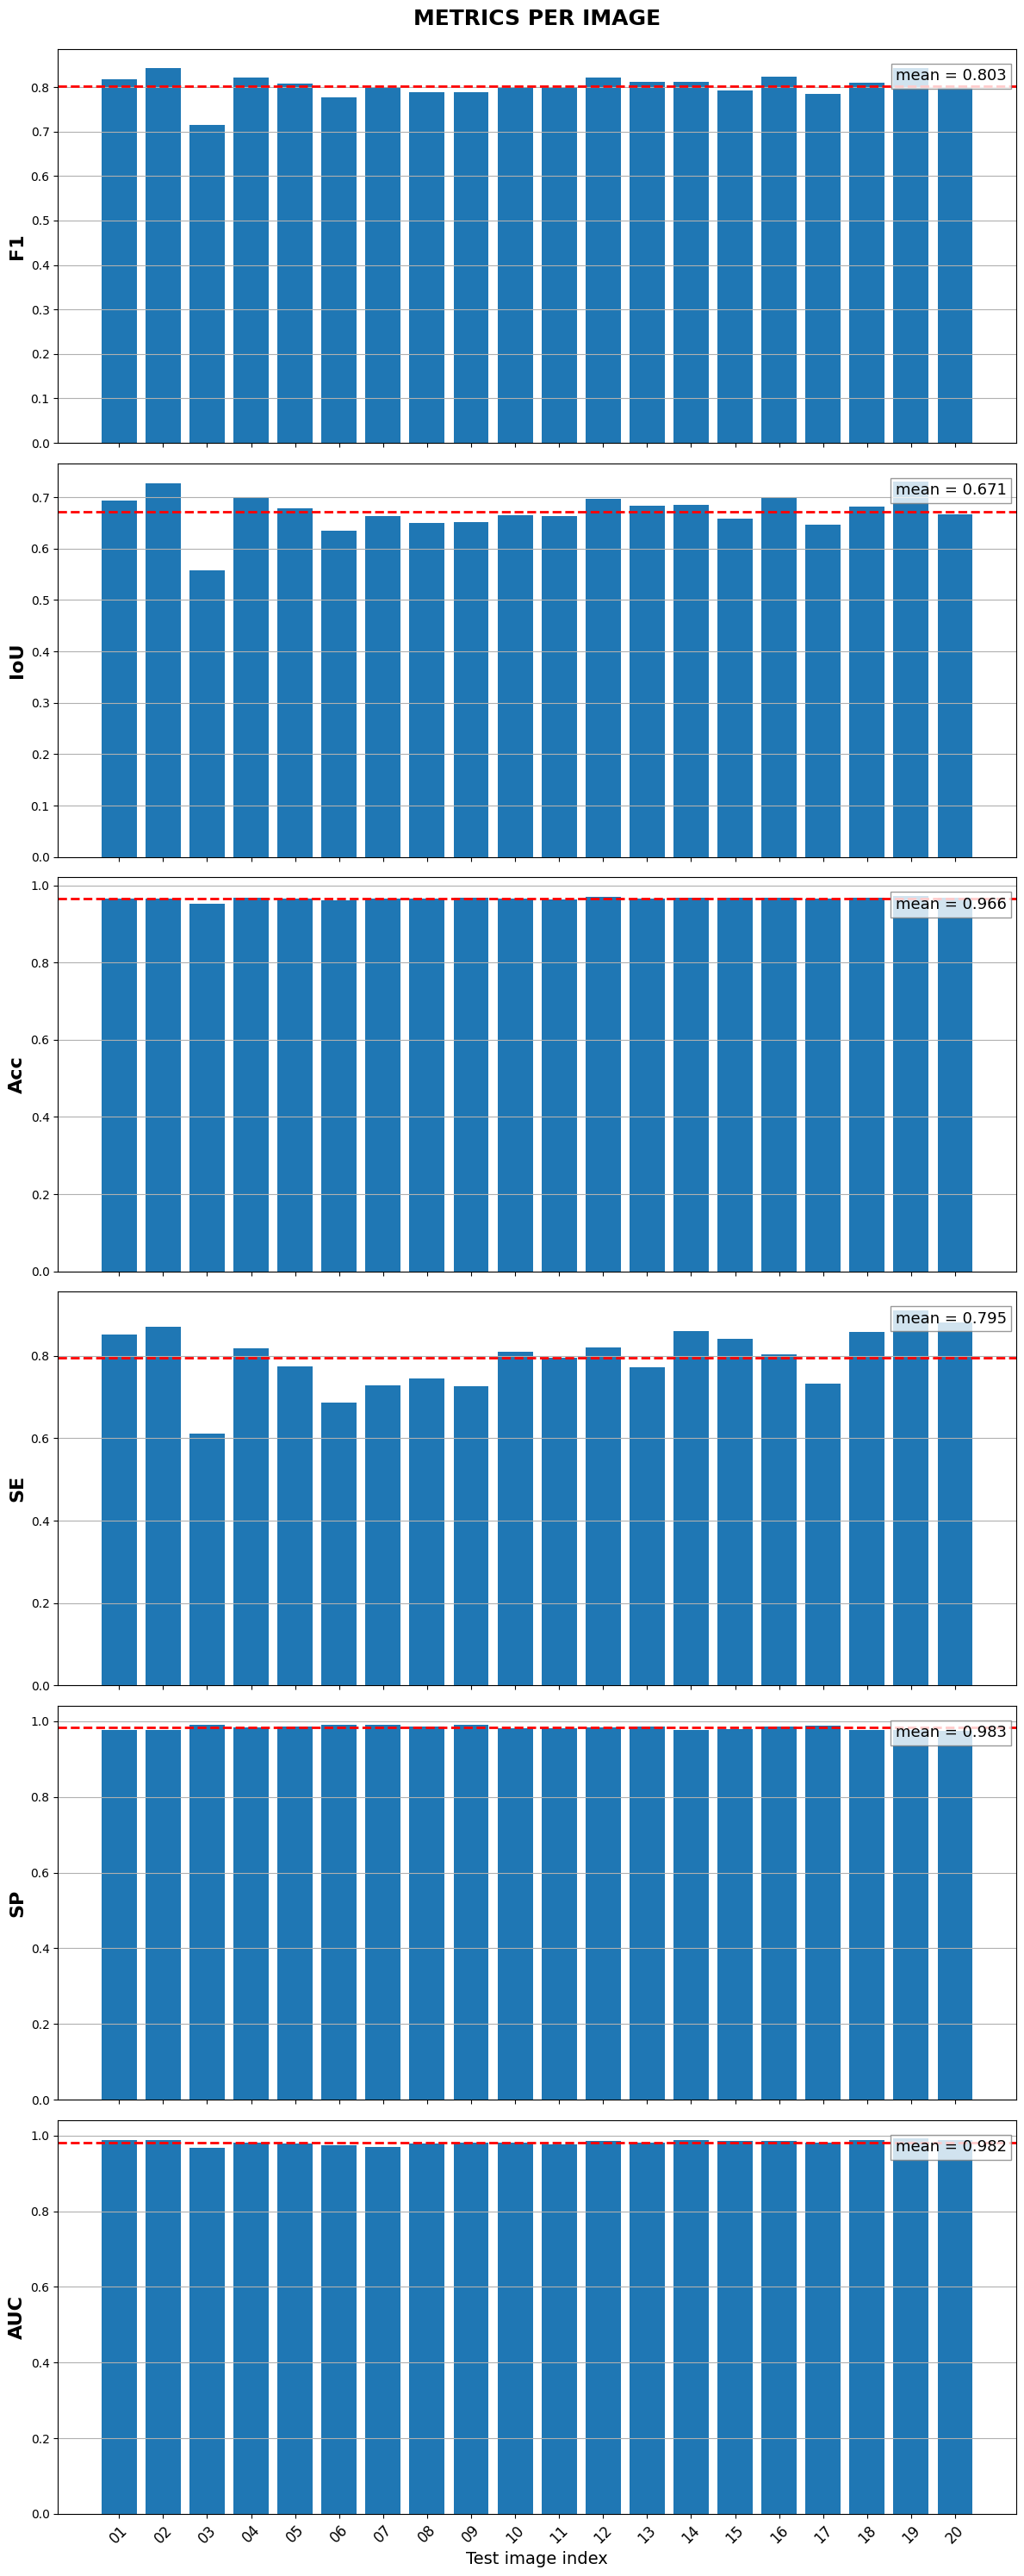

Sauvegardé : /home/usrs/hnoel/Tohoku/Monai/UUNET/UUNET_DRIVE_v1/per_image_metrics.png


In [35]:
# ==========================================================
#   Comparison of the images — Standalone (NO FOV version)
#   Fusion of the 3 original cells — produces final figure
# ==========================================================

# ---- HELPER FUNCTIONS ----

def confusion_binary(pred_bin: torch.Tensor, gt_bin: torch.Tensor):
    pred_bin = pred_bin.bool()
    gt_bin   = gt_bin.bool()
    TP = (pred_bin & gt_bin).sum().item()
    FP = (pred_bin & ~gt_bin).sum().item()
    FN = (~pred_bin & gt_bin).sum().item()
    TN = (~pred_bin & ~gt_bin).sum().item()
    return TP, FP, FN, TN


def metrics_from_conf(TP, FP, FN, TN):
    eps = 1e-7
    Acc  = (TP + TN) / max(TP + TN + FP + FN, eps)
    SE   = TP / max(TP + FN, eps)
    SP   = TN / max(TN + FP, eps)
    Prec = TP / max(TP + FP, eps)
    F1   = 2 * Prec * SE / max(Prec + SE, eps)
    IoU  = TP / max(TP + FP + FN, eps)
    return F1, IoU, Acc, SE, SP


def auc_from_logits_one_class(logits_1img, gt_1img, cls):
    with torch.no_grad():
        probs = F.softmax(logits_1img.unsqueeze(0), dim=1)[0]
        prob_cls = probs[cls]

        y_score = prob_cls.view(-1).cpu().numpy()
        y_true  = (gt_1img.view(-1) == cls).cpu().numpy().astype(np.uint8)

        if (y_true == 1).sum() == 0 or (y_true == 0).sum() == 0:
            return float("nan")

        try:
            return float(roc_auc_score(y_true, y_score))
        except:
            return float("nan")


# ==========================================================
#               METRICS PER IMAGE — FULL IMAGE ONLY
# ==========================================================

model.eval()

metric_names = ["F1", "IoU", "Acc", "SE", "SP", "AUC"]
scores_full = {m: [] for m in metric_names}

img_indices = []

with torch.no_grad():
    current_idx = 0
    for batch in test_loader:
        imgs   = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits  = model(imgs)
        if isinstance(logits, list):
                logits = logits[0]
        preds   = logits.argmax(dim=1)
        targets = labels.squeeze(1)

        for i in range(imgs.size(0)):
            gt_i   = targets[i]
            pred_i = preds[i]
            log_i  = logits[i]

            pred_v = (pred_i == VESSEL_CLASS)
            gt_v   = (gt_i == VESSEL_CLASS)

            TP, FP, FN, TN = confusion_binary(pred_v, gt_v)
            F1, IoU, Acc, SE, SP = metrics_from_conf(TP, FP, FN, TN)
            AUC = auc_from_logits_one_class(log_i, gt_i, VESSEL_CLASS)

            scores_full["F1"].append(F1)
            scores_full["IoU"].append(IoU)
            scores_full["Acc"].append(Acc)
            scores_full["SE"].append(SE)
            scores_full["SP"].append(SP)
            scores_full["AUC"].append(AUC)

            img_indices.append(current_idx)
            current_idx += 1

# ==========================================================
#               FINAL FIGURE (SAME AS LAST CELL)
#           BUT SINGLE COLUMN (NO FOV IN DATASET)
# ==========================================================

metric_names = ["F1", "IoU", "Acc", "SE", "SP", "AUC"]

fig, axes = plt.subplots(
    nrows=6, ncols=1, figsize=(12, 30), sharex=True
)

axes = axes.ravel()

axes[0].set_title("METRICS PER IMAGE", fontsize=18, fontweight="bold", pad=20)

for row, m in enumerate(metric_names):

    vals = np.array(scores_full[m], dtype=float)
    mean_val = np.nanmean(vals)

    ax = axes[row]
    ax.bar(np.arange(len(vals)), vals)
    ax.axhline(mean_val, color="red", linestyle="--", linewidth=2)

    ax.text(
        0.99, 0.92,
        f"mean = {mean_val:.3f}",
        transform=ax.transAxes,
        horizontalalignment="right",
        fontsize=13,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

    ax.set_ylabel(m, fontsize=16, fontweight="bold")
    ax.grid(True, axis="y")


axes[-1].set_xticks(np.arange(len(vals)))
axes[-1].set_xticklabels(
    [f"{i+1:02d}" for i in range(len(vals))],
    rotation=45,
    fontsize=12
)
axes[-1].set_xlabel("Test image index", fontsize=14)

plt.tight_layout()

out_path = data_dir / "per_image_metrics.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Sauvegardé : {out_path}")


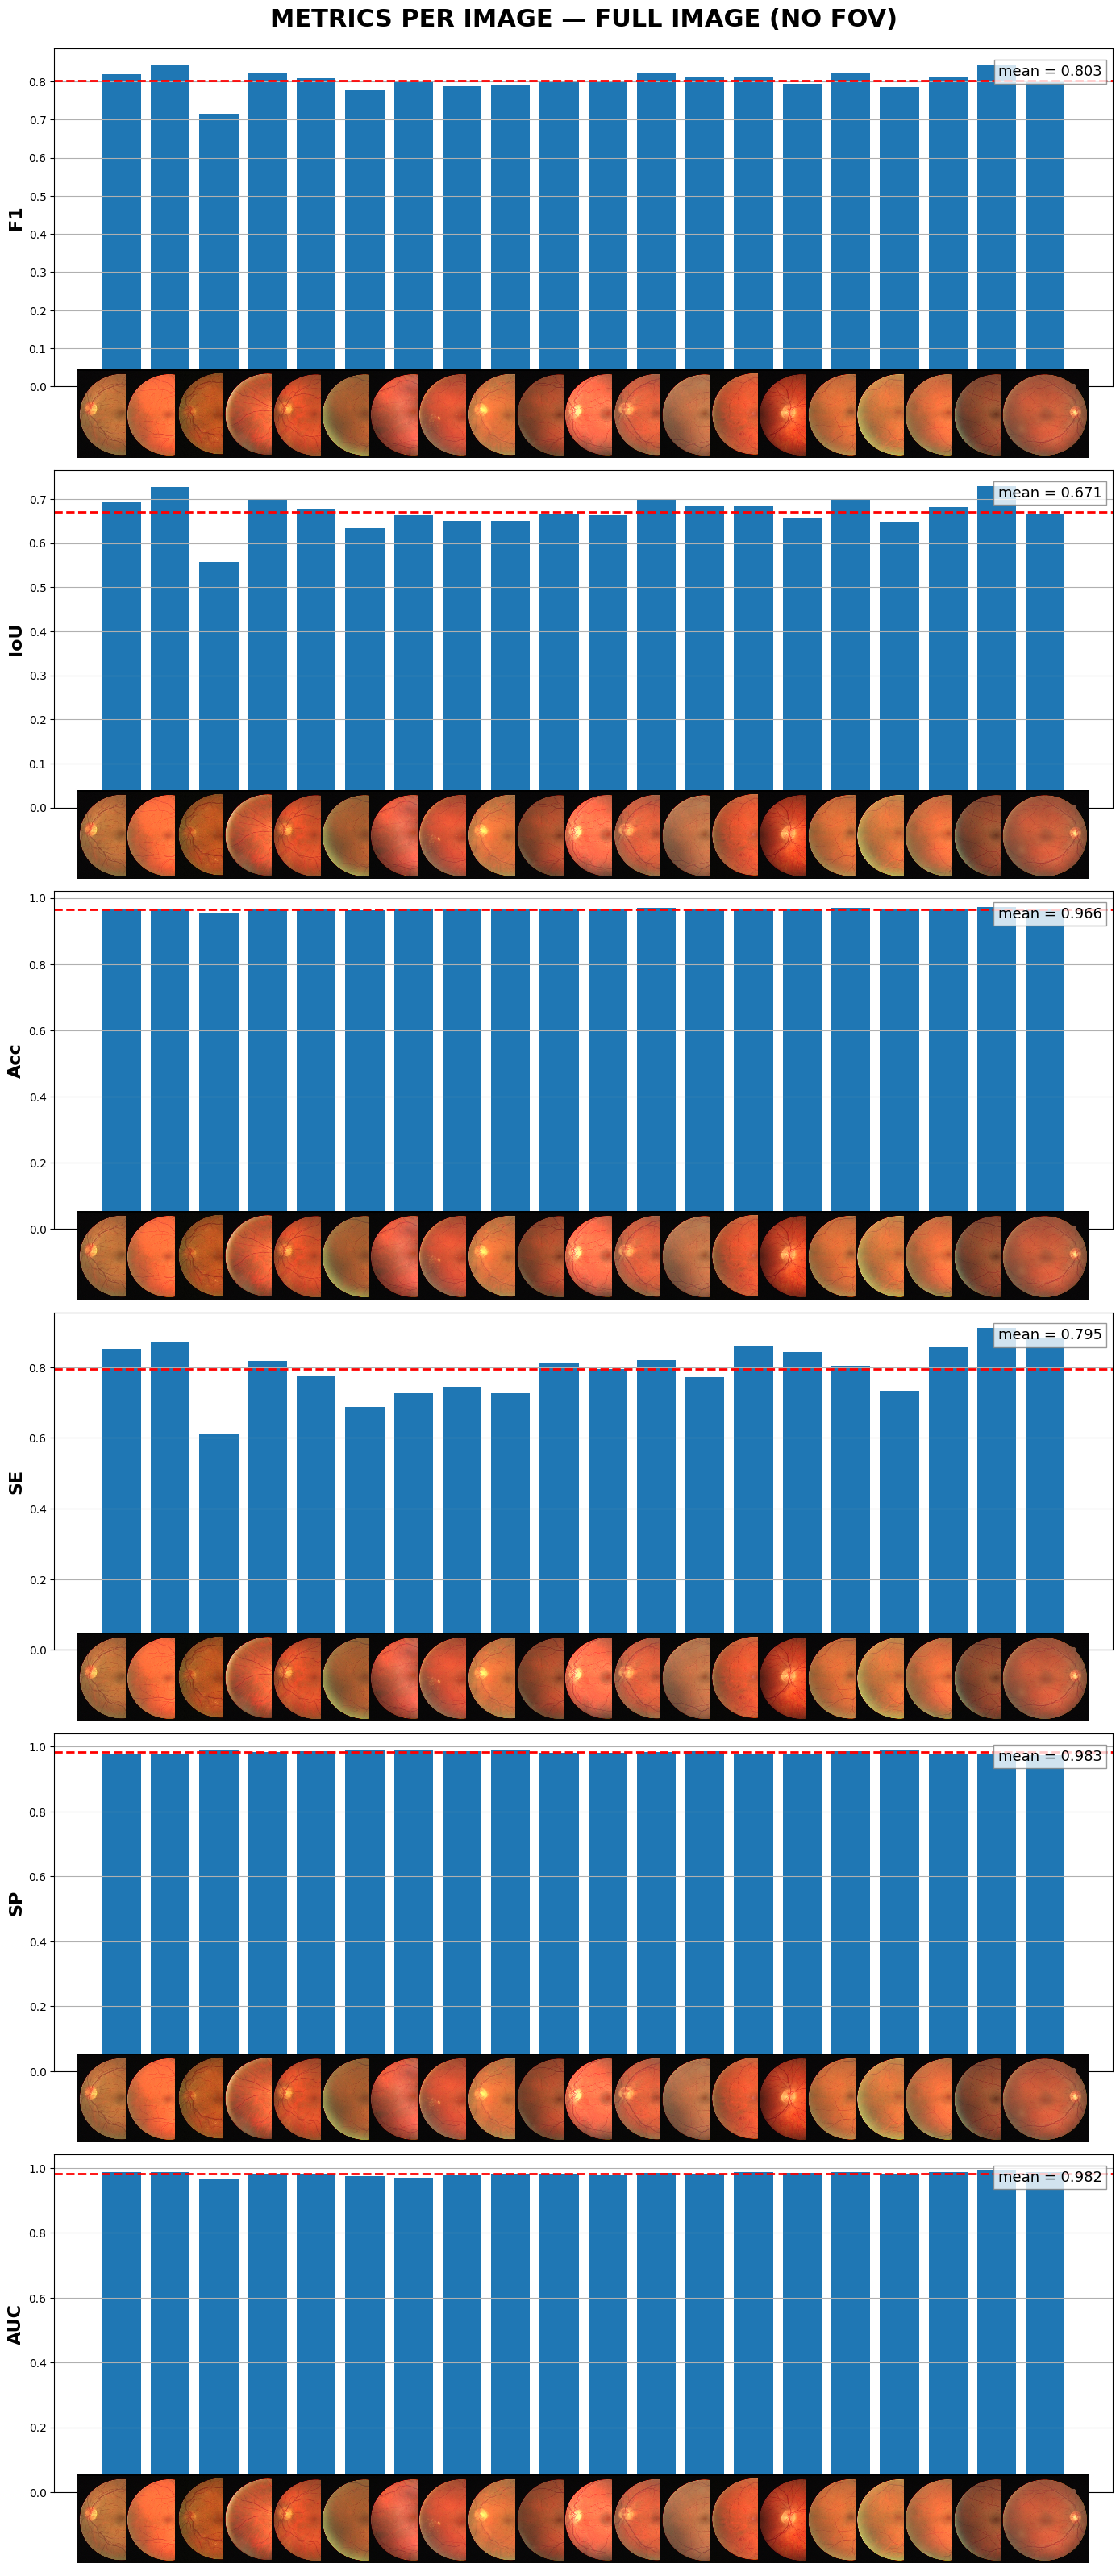

Sauvegardé : /home/usrs/hnoel/Tohoku/Monai/UUNET/UUNET_DRIVE_v1/per_image_metrics_FULLIMAGE_with_thumbnails.png


In [36]:
# ==========================================================
#   Comparison of the images — Standalone (NO FOV)
#   + Images below histogram bars
# ==========================================================

# ---- HELPER FUNCTIONS ----

def confusion_binary(pred_bin: torch.Tensor, gt_bin: torch.Tensor):
    pred_bin = pred_bin.bool()
    gt_bin   = gt_bin.bool()
    TP = (pred_bin & gt_bin).sum().item()
    FP = (pred_bin & ~gt_bin).sum().item()
    FN = (~pred_bin & gt_bin).sum().item()
    TN = (~pred_bin & ~gt_bin).sum().item()
    return TP, FP, FN, TN


def metrics_from_conf(TP, FP, FN, TN):
    eps = 1e-7
    Acc  = (TP + TN) / max(TP + TN + FP + FN, eps)
    SE   = TP / max(TP + FN, eps)
    SP   = TN / max(TN + FP, eps)
    Prec = TP / max(TP + FP, eps)
    F1   = 2 * Prec * SE / max(Prec + SE, eps)
    IoU  = TP / max(TP + FP + FN, eps)
    return F1, IoU, Acc, SE, SP


def auc_from_logits_one_class(logits_1img, gt_1img, cls):
    with torch.no_grad():
        probs = F.softmax(logits_1img.unsqueeze(0), dim=1)[0]
        prob_cls = probs[cls]

        y_score = prob_cls.view(-1).cpu().numpy()
        y_true  = (gt_1img.view(-1) == cls).cpu().numpy().astype(np.uint8)

        if (y_true == 1).sum() == 0 or (y_true == 0).sum() == 0:
            return float("nan")

        try:
            return float(roc_auc_score(y_true, y_score))
        except:
            return float("nan")


# ==========================================================
#               METRICS PER IMAGE — FULL IMAGE ONLY
# ==========================================================

model.eval()

metric_names = ["F1", "IoU", "Acc", "SE", "SP", "AUC"]
scores_full = {m: [] for m in metric_names}
img_indices = []
all_images = []  # stockage des images brutes pour affichage

with torch.no_grad():
    current_idx = 0
    for batch in test_loader:
        imgs   = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits  = model(imgs)
        if isinstance(logits, list):
                logits = logits[0]
        preds   = logits.argmax(dim=1)
        targets = labels.squeeze(1)

        for i in range(imgs.size(0)):
            gt_i   = targets[i]
            pred_i = preds[i]
            log_i  = logits[i]

            # Sauvegarde image originale pour affichage
            all_images.append(imgs[i].cpu().permute(1, 2, 0).numpy())

            pred_v = (pred_i == VESSEL_CLASS)
            gt_v   = (gt_i == VESSEL_CLASS)

            TP, FP, FN, TN = confusion_binary(pred_v, gt_v)
            F1, IoU, Acc, SE, SP = metrics_from_conf(TP, FP, FN, TN)
            AUC = auc_from_logits_one_class(log_i, gt_i, VESSEL_CLASS)

            scores_full["F1"].append(F1)
            scores_full["IoU"].append(IoU)
            scores_full["Acc"].append(Acc)
            scores_full["SE"].append(SE)
            scores_full["SP"].append(SP)
            scores_full["AUC"].append(AUC)

            img_indices.append(current_idx)
            current_idx += 1

# ==========================================================
#                FINAL FIGURE WITH IMAGES UNDER BARS
# ==========================================================

metric_names = ["F1", "IoU", "Acc", "SE", "SP", "AUC"]

fig, axes = plt.subplots(
    nrows=6, ncols=1, figsize=(14, 32), sharex=True
)

axes = axes.ravel()

axes[0].set_title("METRICS PER IMAGE — FULL IMAGE (NO FOV)", fontsize=22, fontweight="bold", pad=20)

n_images = len(all_images)
x = np.arange(n_images)

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def add_image_under_bar(ax, img, xpos, y_bottom):
    imagebox = OffsetImage(img, zoom=0.13)
    ab = AnnotationBbox(imagebox, (xpos, y_bottom - 0.08),
                        xycoords=("data", "axes fraction"),
                        frameon=False)
    ax.add_artist(ab)

for row, m in enumerate(metric_names):

    vals = np.array(scores_full[m], dtype=float)
    mean_val = np.nanmean(vals)

    ax = axes[row]
    bars = ax.bar(x, vals)

    # Ligne de moyenne
    ax.axhline(mean_val, color="red", linestyle="--", linewidth=2)
    ax.text(
        0.99, 0.92,
        f"mean = {mean_val:.3f}",
        transform=ax.transAxes,
        horizontalalignment="right",
        fontsize=13,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

    # Ajout des images sous chaque barre
    for j in range(n_images):
        img = all_images[j]
        add_image_under_bar(ax, img, j, 0)

    ax.set_ylabel(m, fontsize=16, fontweight="bold")
    ax.grid(True, axis="y")

axes[-1].set_xticks(x)
axes[-1].set_xticklabels([f"{i+1:02d}" for i in x], rotation=45, fontsize=12)
axes[-1].set_xlabel("Test image index", fontsize=14)

plt.tight_layout()

out_path = data_dir / "per_image_metrics_FULLIMAGE_with_thumbnails.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Sauvegardé : {out_path}")


In [ ]:
# ==========================================================
#   Overlay GT vs Pred — With legend, filenames, saving
# ==========================================================

model.eval()

# 📁 Dossier pour sauvegarder les overlays
overlay_dir = data_dir / "overlays_test"
overlay_dir.mkdir(parents=True, exist_ok=True)

# Pour récupérer le nom réel des fichiers test (triés)
test_img_paths = sorted(list(test_images_dir.glob("*.png")))

with torch.no_grad():
    for idx, batch in enumerate(test_loader):
        imgs    = batch["image"].to(device)      # (B,3,H,W)
        labels  = batch["label"].to(device)      # (B,1,H,W)
        logits  = model(imgs)
        if isinstance(logits, list):
                logits = logits[0]                  # (B,2,H,W)
        preds   = logits.argmax(dim=1)
        targets = labels.squeeze(1)

        batch_size = imgs.size(0)

        for i in range(batch_size):

            # Récupérer nom réel du fichier
            global_index = idx * batch_size + i
            img_name = test_img_paths[global_index].name

            # Tensors -> numpy
            gt  = (targets[i].cpu().numpy() == VESSEL_CLASS).astype(np.uint8)
            pr  = (preds[i].cpu().numpy()    == VESSEL_CLASS).astype(np.uint8)
            H, W = gt.shape

            # Overlay RGB
            overlay = np.zeros((H, W, 3), dtype=float)

            # TN (0,0) → noir
            mask_tn = (gt == 0) & (pr == 0)
            overlay[mask_tn] = [0, 0, 0]

            # TP (1,1) → vert
            mask_tp = (gt == 1) & (pr == 1)
            overlay[mask_tp] = [0, 1, 0]

            # FP (0,1) → rouge
            mask_fp = (gt == 0) & (pr == 1)
            overlay[mask_fp] = [1, 0, 0]

            # FN (1,0) → blanc
            mask_fn = (gt == 1) & (pr == 0)
            overlay[mask_fn] = [1, 1, 1]

            # ======== FIGURE ========
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.imshow(overlay)
            ax.axis("off")
            ax.set_title(f"GT vs Pred — {img_name}", fontsize=14)

            # ======== LÉGENDE ========
            # On crée une "fake" légende avec des patches colorés
            import matplotlib.patches as mpatches
            legend_elems = [
                mpatches.Patch(color="black", label="TN: Background correct"),
                mpatches.Patch(color="green", label="TP: Vessel correct"),
                mpatches.Patch(color="red",   label="FP: Predicted vessel but GT background"),
                mpatches.Patch(facecolor="white", edgecolor="black", linewidth=1.5, label="FN: Missed vessel")
,
            ]
            ax.legend(handles=legend_elems, loc="lower center",
                      bbox_to_anchor=(0.5, -0.08),
                      fancybox=True, framealpha=1,
                      ncol=2)

            # ======== SAUVEGARDE ========
            save_path = overlay_dir / f"overlay_{global_index:02d}.png"
            plt.savefig(save_path, dpi=200, bbox_inches="tight")
            plt.show()

print(f"Overlays enregistrés dans : {overlay_dir}")

IndexError: list index out of range

In [38]:
# ==========================================================
#   Overlay GT vs Pred — With legend, filenames, saving
#   FIX: avoid IndexError by using a global counter, and guard mismatches
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch

model.eval()

# 📁 Dossier pour sauvegarder les overlays
overlay_dir = data_dir / "overlays_test"
overlay_dir.mkdir(parents=True, exist_ok=True)

# Pour récupérer le nom réel des fichiers test (triés)
test_img_paths = sorted(list(test_images_dir.glob("*.png")))
n_files = len(test_img_paths)

with torch.no_grad():
    global_index = 0  # compteur global sur tous les batches

    for batch in test_loader:
        imgs   = batch["image"].to(device)  # (B,3,H,W)
        labels = batch["label"].to(device)  # (B,1,H,W)

        logits = model(imgs)
        if isinstance(logits, list):
            logits = logits[0]  # (B,2,H,W)

        preds   = logits.argmax(dim=1)   # (B,H,W)
        targets = labels.squeeze(1)      # (B,H,W)

        batch_size = imgs.size(0)

        for i in range(batch_size):
            # Si jamais test_loader sort + d'items que de fichiers listés
            if global_index >= n_files:
                print(
                    f"[WARN] global_index={global_index} >= n_files={n_files}. "
                    "Arrêt pour éviter un IndexError (mismatch loader vs dossier)."
                )
                break

            img_name = test_img_paths[global_index].name

            # Tensors -> numpy
            gt = (targets[i].detach().cpu().numpy() == VESSEL_CLASS).astype(np.uint8)
            pr = (preds[i].detach().cpu().numpy()    == VESSEL_CLASS).astype(np.uint8)
            H, W = gt.shape

            # Overlay RGB
            overlay = np.zeros((H, W, 3), dtype=float)

            # TN (0,0) → noir
            mask_tn = (gt == 0) & (pr == 0)
            overlay[mask_tn] = [0, 0, 0]

            # TP (1,1) → vert
            mask_tp = (gt == 1) & (pr == 1)
            overlay[mask_tp] = [0, 1, 0]

            # FP (0,1) → rouge
            mask_fp = (gt == 0) & (pr == 1)
            overlay[mask_fp] = [1, 0, 0]

            # FN (1,0) → blanc
            mask_fn = (gt == 1) & (pr == 0)
            overlay[mask_fn] = [1, 1, 1]

            # ======== FIGURE ========
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.imshow(overlay)
            ax.axis("off")
            ax.set_title(f"GT vs Pred — {img_name}", fontsize=14)

            # ======== LÉGENDE ========
            legend_elems = [
                mpatches.Patch(color="black", label="TN: Background correct"),
                mpatches.Patch(color="green", label="TP: Vessel correct"),
                mpatches.Patch(color="red",   label="FP: Predicted vessel but GT background"),
                mpatches.Patch(facecolor="white", edgecolor="black", linewidth=1.5, label="FN: Missed vessel"),
            ]
            ax.legend(
                handles=legend_elems,
                loc="lower center",
                bbox_to_anchor=(0.5, -0.08),
                fancybox=True,
                framealpha=1,
                ncol=2,
            )

            # ======== SAUVEGARDE ========
            save_path = overlay_dir / f"overlay_{global_index:02d}.png"
            plt.savefig(save_path, dpi=200, bbox_inches="tight")
            plt.show()
            plt.close(fig)  # évite d'accumuler des figures en mémoire

            global_index += 1

        # break outer loop too if we hit mismatch stop condition
        if global_index >= n_files:
            break

print(f"Overlays enregistrés dans : {overlay_dir}")


[WARN] global_index=0 >= n_files=0. Arrêt pour éviter un IndexError (mismatch loader vs dossier).
Overlays enregistrés dans : /home/usrs/hnoel/Tohoku/Monai/UUNET/UUNET_DRIVE_v1/overlays_test
